# 11 수학용 도구

## 11.1 근사화

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
def f(x):
    return np.sin(x) + 0.5 * x

In [4]:
def create_plot(x, y, styles, labels, axlabels):
    plt.figure(figsize=(10,6))
    for i in range(len(x)):
        plt.plot(x[i], y[i], styles[i], label=labels[i])
        plt.xlabel(axlabels[0])
        plt.ylabel(axlabels[1])
    plt.legend(loc=0)
    plt.show()

In [5]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 50)

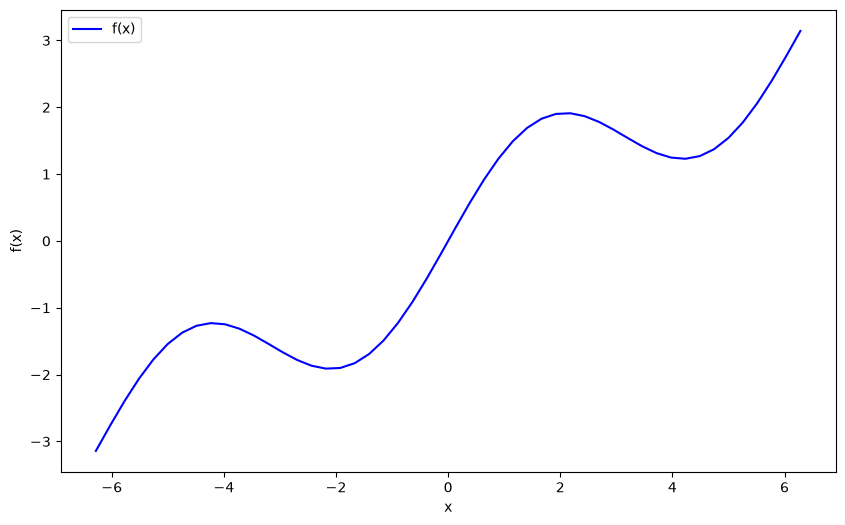

In [6]:
create_plot([x], [f(x)], ['b'], ['f(x)'], ['x', 'f(x)'])

### 11.1.1 회귀법 Regression

**회귀법의 최적화 문제**

$\min_{\alpha_1, \dots, \alpha_D} \dfrac{1}{I} \sum_{i=1}^{I} \left( y_i - \sum_{d=1}^{D} \alpha_d \cdot b_d (x_i) \right)^2$

- 기저 함수 집합 $b_d, (d \in \{ 1, \dots, D \}$와 기저 함수를 조합하기 위한 최적 매개변수 $\alpha_1^*, \dots, \alpha_D^*$를 찾는 작업
- $y_i$: $i \in \{ 1, \dots, I \}$에 대해 $y_i \equiv f(x_i)$를 만족하는 점

**단항식 기저 함수**

- `np.polyfit(x, y, deg)`: 다항식 회귀
- `np.polyval(p, x)`: 다항식 값 계산

In [7]:
res = np.polyfit(x, f(x), deg=1, full=True)

In [8]:
res

(array([ 4.28841952e-01, -6.47663139e-17]),
 array([21.03238686]),
 np.int32(2),
 array([1., 1.]),
 np.float64(1.1102230246251565e-14))

In [9]:
ry = np.polyval(res[0], x)

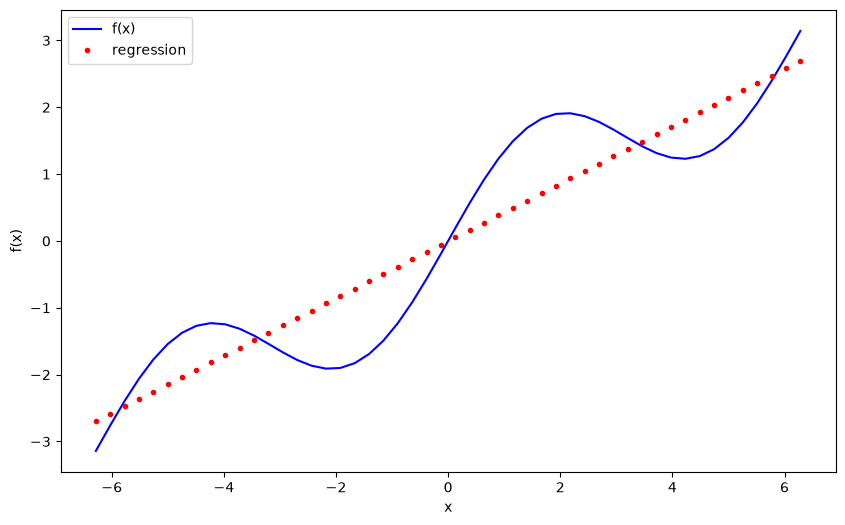

In [10]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

In [11]:
reg = np.polyfit(x, f(x), deg=5)
ry = np.polyval(reg, x)

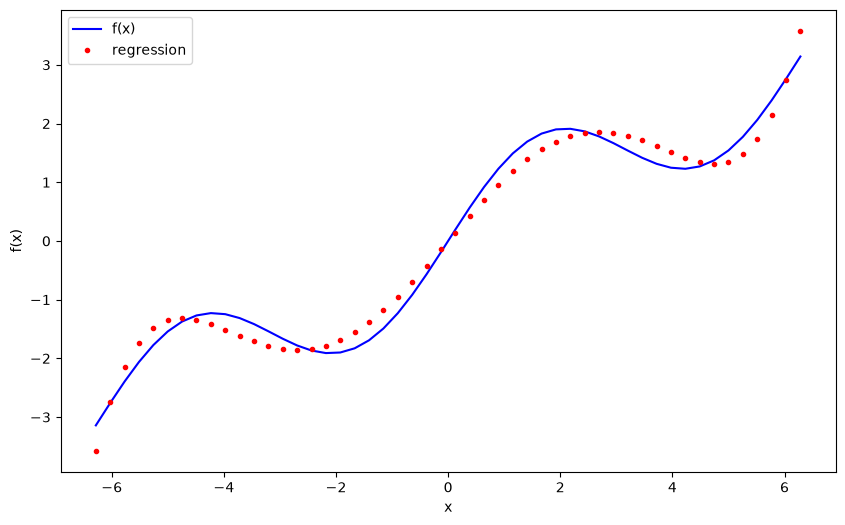

In [12]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

In [13]:
reg = np.polyfit(x, f(x), deg=7)
ry = np.polyval(reg, x)

In [14]:
np.allclose(f(x), ry)

False

In [15]:
np.mean((f(x) - ry) ** 2)

np.float64(0.0017769134759517582)

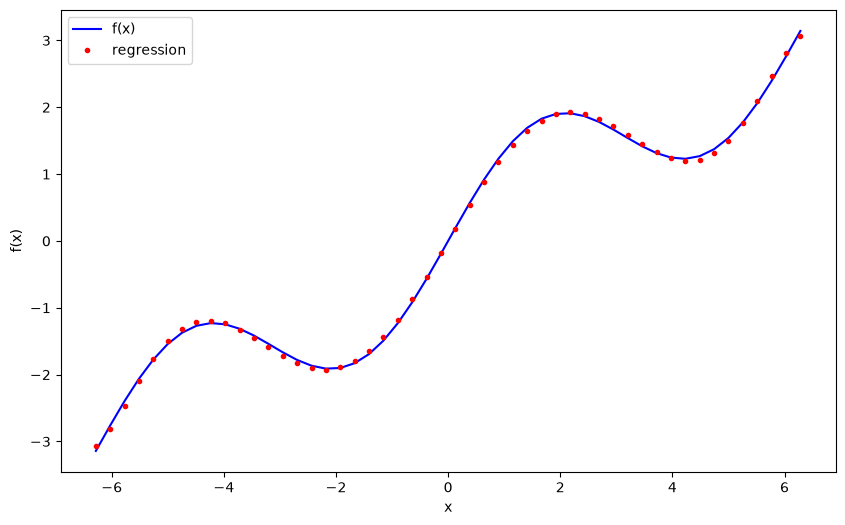

In [16]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

**개별 기저 함수**

- `np.linalg.lstsq(a, b)`: 최소제곱해 계산

In [17]:
matrix = np.zeros((len(x), 3 + 1))
matrix[:, 3] = x ** 3
matrix[:, 2] = x ** 2
matrix[:, 1] = x
matrix[:, 0] = 1

In [18]:
reg = np.linalg.lstsq(matrix, f(x), rcond=None)[0]

In [19]:
reg.round(4)

array([ 0.    ,  0.5628, -0.    , -0.0054])

In [20]:
ry = np.dot(matrix, reg)

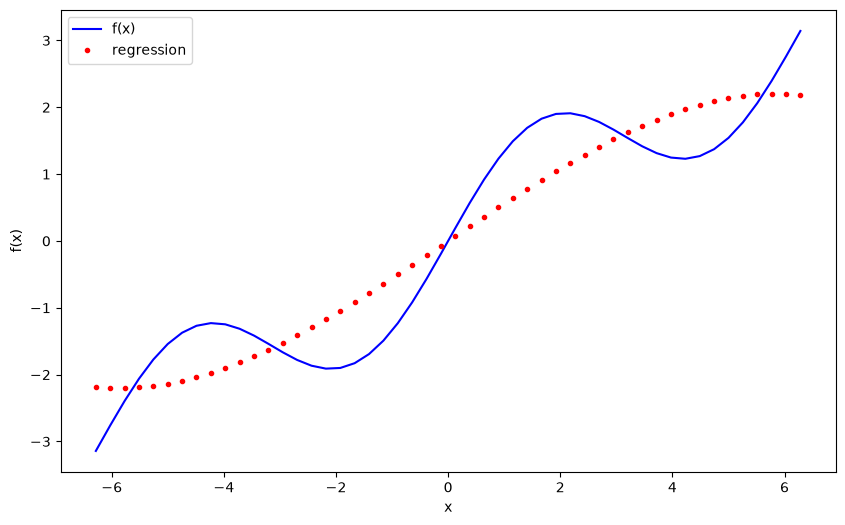

In [21]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

In [22]:
matrix[:, 3] = np.sin(x)

In [23]:
reg = np.linalg.lstsq(matrix, f(x), rcond=None)[0]

In [24]:
reg.round(4)

array([0. , 0.5, 0. , 1. ])

In [25]:
ry = np.dot(matrix, reg)

In [26]:
np.allclose(f(x), ry)

True

In [27]:
np.mean((f(x) - ry) ** 2)

np.float64(2.655164058530019e-31)

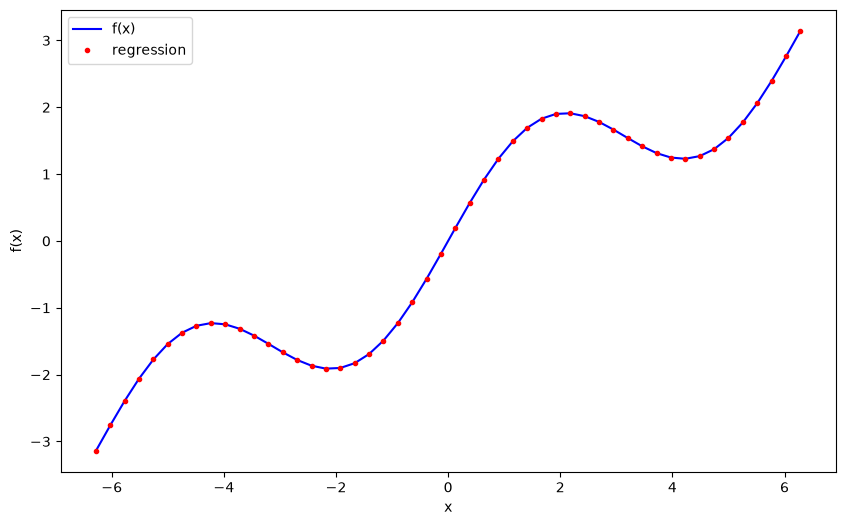

In [28]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

**잡음이 있는 데이터**

In [29]:
xn = np.linspace(-2 * np.pi, 2 * np.pi, 50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25 * np.random.standard_normal(len(xn))

In [30]:
reg = np.polyfit(xn, yn, 7)
ry = np.polyval(reg, xn)

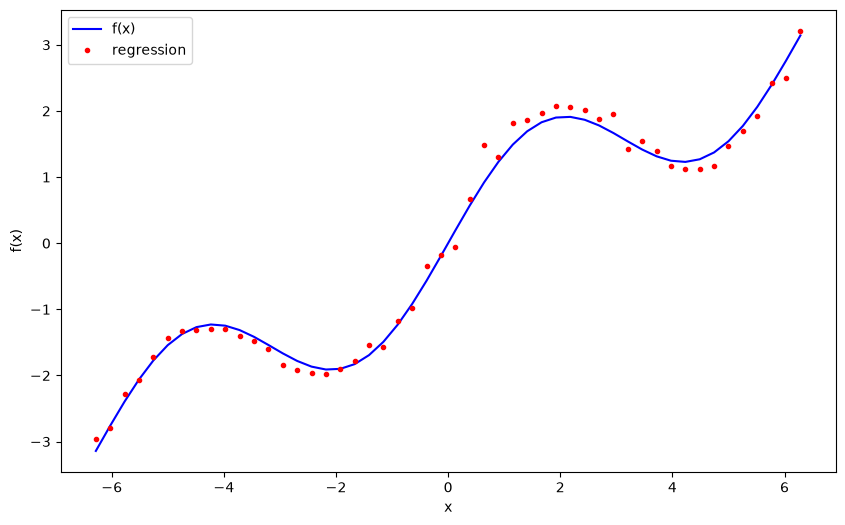

In [31]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

**정렬되지 않은 상태**

In [32]:
xu = np.random.rand(50) * 4 * np.pi - 2 * np.pi
yu = f(xu)

In [33]:
print(xu[:10].round(2))
print(yu[:10].round(2))

[-4.41  3.29  5.22 -5.13 -3.72 -1.4  -6.11  1.97  1.41  2.22]
[-1.25  1.5   1.73 -1.65 -1.31 -1.68 -2.88  1.91  1.69  1.91]


In [34]:
reg = np.polyfit(xu, yu, 5)
ry = np.polyval(reg, xu)

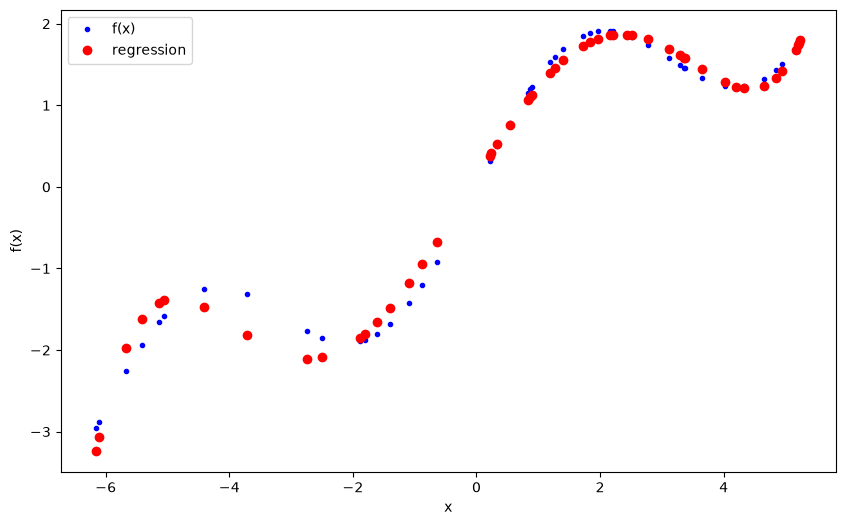

In [35]:
create_plot([xu, xu], [yu, ry], ['b.', 'ro'], ['f(x)', 'regression'], ['x', 'f(x)'])

**다차원 데이터**

In [36]:
def fm(p):
    x, y = p
    return np.sin(x) + 0.25 * x + np.sqrt(y) + 0.05 * y ** 2

In [37]:
x = np.linspace(0, 10, 20)
y = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x, y)

In [38]:
Z = fm((X, Y))
x = X.flatten()
y = Y.flatten()

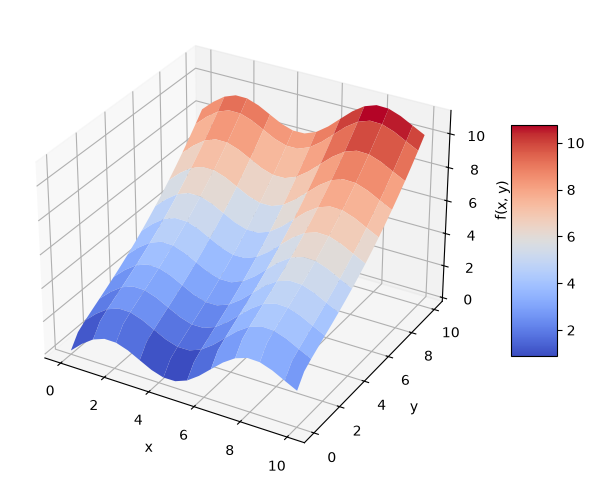

In [39]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, rstride=2, cstride=2,
                       cmap='coolwarm', linewidth=0.5,
                       antialiased=True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [40]:
matrix = np.zeros((len(x), 6 + 1))
matrix[:, 6] = np.sqrt(y)
matrix[:, 5] = np.sin(x)
matrix[:, 4] = y ** 2
matrix[:, 3] = x ** 2
matrix[:, 2] = y
matrix[:, 1] = x
matrix[:, 0] = 1

In [41]:
reg = np.linalg.lstsq(matrix, fm((x, y)), rcond=None)[0]

In [42]:
RZ = np.dot(matrix, reg).reshape((20,20))

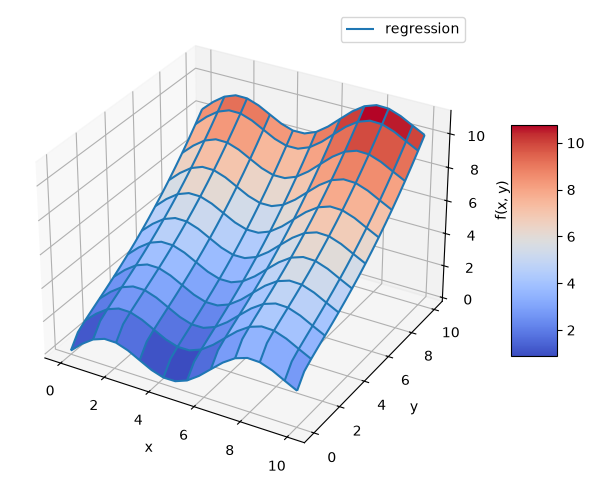

In [43]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

surf1 = ax.plot_surface(X, Y, Z, rstride=2, cstride=2,
                        cmap='coolwarm', linewidth=0.5,
                        antialiased=True)
surf2 = ax.plot_wireframe(X, Y, RZ, rstride=2, cstride=2,
                          label='regression')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.show()

### 11.1.2 보간법 Interpolation

- $x$차원의 정렬된 관측점이 주어졌을 때, **두 개의 이웃하는 관측점 사이의 자료를 계산하는 보간 함수**를 만드는 것
- 관측점 자체도 정확하게 재현,
- 각 관측점에서 연속 미분 가능한 함수(continuously differentiable function)여야 함.
- 연속 미분 가능하기 위해서는 보간 함수가 최소 3차 이상, 즉 **큐빅 스플라인 함수(cubic spline function)** 여야 함.
- 이 방법론 자체는 2차 보간 함수나 1차 선형 보간 함수의 경우에도 적용 가능

In [44]:
import scipy.interpolate as spi

In [45]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 25)

In [46]:
def f(x):
    return np.sin(x) + 0.5 * x

In [47]:
ipo = spi.splrep(x, f(x), k=1)

In [48]:
iy = spi.splev(x, ipo)

In [49]:
np.allclose(f(x), iy)

True

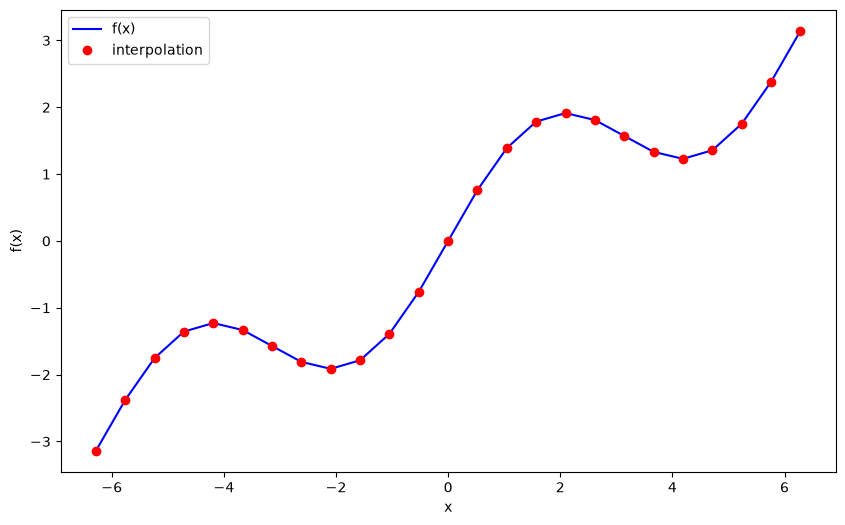

In [50]:
create_plot([x, x], [f(x), iy], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])

- `scipy.interpolate.splrep(x, y, k=n)`: 스플라인 보간 준비
- `scipy.interpolate.splev(x_new, tck)`: 스플라인 값 계산

In [51]:
xd = np.linspace(1.0, 3.0, 50)
iyd = spi.splev(xd, ipo)

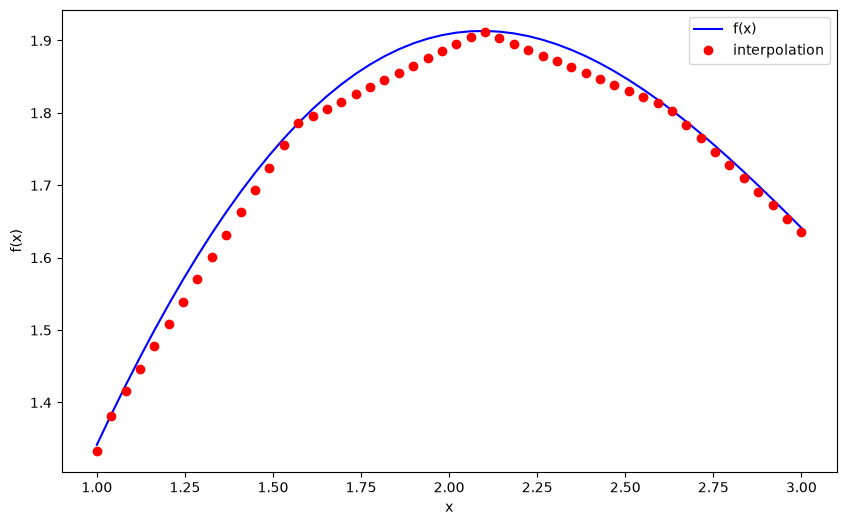

In [52]:
create_plot([xd, xd], [f(xd), iyd], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])

In [53]:
ipo = spi.splrep(x, f(x), k=3)
iyd = spi.splev(xd, ipo)

In [54]:
np.allclose(f(xd), iyd)

False

In [55]:
np.mean((f(xd) - iyd) ** 2)

np.float64(1.1349319851457788e-08)

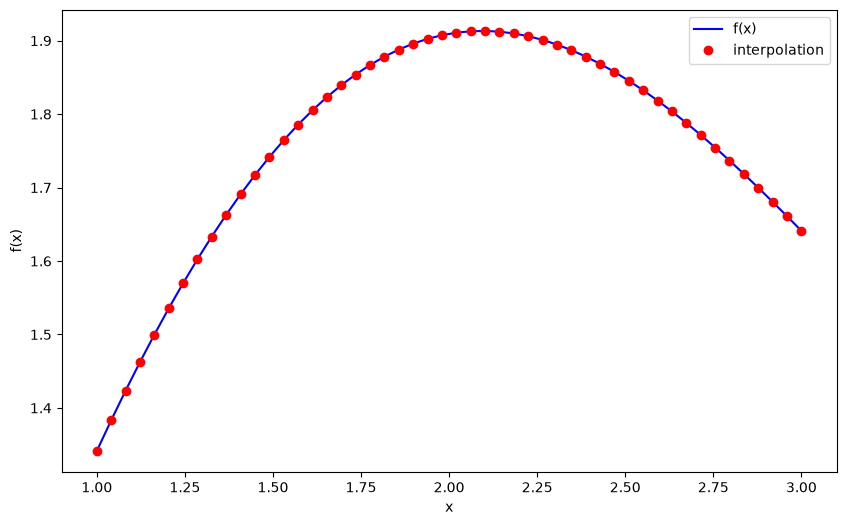

In [56]:
create_plot([xd, xd], [f(xd), iyd], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])

In [57]:
ipo

(array([-6.28318531, -6.28318531, -6.28318531, -6.28318531, -5.23598776,
        -4.71238898, -4.1887902 , -3.66519143, -3.14159265, -2.61799388,
        -2.0943951 , -1.57079633, -1.04719755, -0.52359878,  0.        ,
         0.52359878,  1.04719755,  1.57079633,  2.0943951 ,  2.61799388,
         3.14159265,  3.66519143,  4.1887902 ,  4.71238898,  5.23598776,
         6.28318531,  6.28318531,  6.28318531,  6.28318531]),
 array([-3.14159265e+00, -2.61364635e+00, -1.84509979e+00, -1.30952365e+00,
        -1.18786658e+00, -1.30922820e+00, -1.57079489e+00, -1.83237022e+00,
        -1.95370589e+00, -1.83214397e+00, -1.43010721e+00, -7.85172280e-01,
        -3.92936224e-16,  7.85172280e-01,  1.43010721e+00,  1.83214397e+00,
         1.95370589e+00,  1.83237022e+00,  1.57079489e+00,  1.30922820e+00,
         1.18786658e+00,  1.30952365e+00,  1.84509979e+00,  2.61364635e+00,
         3.14159265e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]),
 3)

## 11.2 최적화

In [58]:
def fm(p):
    x, y = p
    return (np.sin(x) + 0.05 * x ** 2 + np.sin(y) + 0.05 * y ** 2)

In [59]:
x = np.linspace(-10, 10, 50)
y = np.linspace(-10, 10, 50)
X, Y = np.meshgrid(x, y)
Z = fm((X, Y))

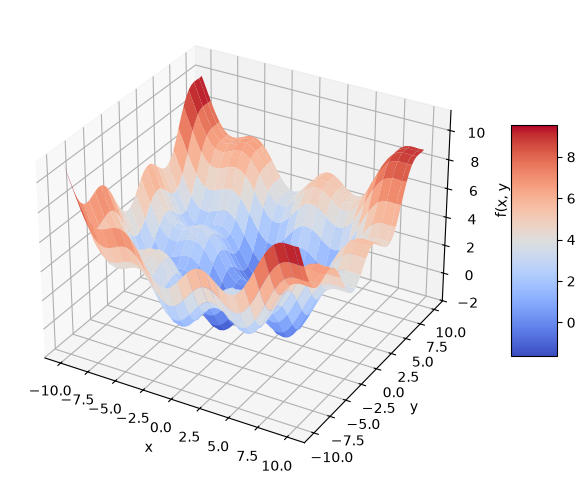

In [60]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, 
                      rstride=2, cstride=2, cmap='coolwarm', linewidth=0.5, antialiased=True)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

### 11.2.1 전역 최적화

- `scipy.optimize.brute(func, ranges)`: 전역 탐색 최적화

In [61]:
import scipy.optimize as sco

In [62]:
def fo(p):
    x, y = p
    z = np.sin(x) + 0.05 * x ** 2 + np.sin(y) + 0.05 * y ** 2
    if output == True:
        print(f'{x:8.4f} | {y:8.4f} | {z:8.4f}')
    return z

In [63]:
output = True
sco.brute(fo, ((-10, 10.1, 5), (-10, 10.1, 5)), finish=None)

-10.0000 | -10.0000 |  11.0880
-10.0000 |  -5.0000 |   7.7529
-10.0000 |   0.0000 |   5.5440
-10.0000 |   5.0000 |   5.8351
-10.0000 |  10.0000 |  10.0000
 -5.0000 | -10.0000 |   7.7529
 -5.0000 |  -5.0000 |   4.4178
 -5.0000 |   0.0000 |   2.2089
 -5.0000 |   5.0000 |   2.5000
 -5.0000 |  10.0000 |   6.6649
  0.0000 | -10.0000 |   5.5440
  0.0000 |  -5.0000 |   2.2089
  0.0000 |   0.0000 |   0.0000
  0.0000 |   5.0000 |   0.2911
  0.0000 |  10.0000 |   4.4560
  5.0000 | -10.0000 |   5.8351
  5.0000 |  -5.0000 |   2.5000
  5.0000 |   0.0000 |   0.2911
  5.0000 |   5.0000 |   0.5822
  5.0000 |  10.0000 |   4.7471
 10.0000 | -10.0000 |  10.0000
 10.0000 |  -5.0000 |   6.6649
 10.0000 |   0.0000 |   4.4560
 10.0000 |   5.0000 |   4.7471
 10.0000 |  10.0000 |   8.9120


array([0., 0.])

In [64]:
output = False
opt1 = sco.brute(fo, ((-10, 10.1, 0.1), (-10, 10.1, 0.1)), finish=None)

In [65]:
opt1

array([-1.4, -1.4])

In [66]:
fm(opt1)

np.float64(-1.7748994599769203)

### 11.2.2 국소 최적화

- `scipy.optimize.fmin(func, x0)`: 지역 최적화

In [67]:
output = True
opt2 = sco.fmin(fo, opt1, xtol=0.001, ftol=0.001, maxiter=15, maxfun=20)

 -1.4000 |  -1.4000 |  -1.7749
 -1.4700 |  -1.4000 |  -1.7743
 -1.4000 |  -1.4700 |  -1.7743
 -1.3300 |  -1.4700 |  -1.7696
 -1.4350 |  -1.4175 |  -1.7756
 -1.4350 |  -1.3475 |  -1.7722
 -1.4088 |  -1.4394 |  -1.7755
 -1.4438 |  -1.4569 |  -1.7751
 -1.4328 |  -1.4427 |  -1.7756
 -1.4591 |  -1.4208 |  -1.7752
 -1.4213 |  -1.4347 |  -1.7757
 -1.4235 |  -1.4096 |  -1.7755
 -1.4305 |  -1.4344 |  -1.7757
 -1.4168 |  -1.4516 |  -1.7753
 -1.4305 |  -1.4260 |  -1.7757
 -1.4396 |  -1.4257 |  -1.7756
 -1.4259 |  -1.4325 |  -1.7757
 -1.4259 |  -1.4241 |  -1.7757
 -1.4304 |  -1.4177 |  -1.7757
 -1.4270 |  -1.4288 |  -1.7757


/var/folders/vr/z_nwsfq529bfbszc8hbs1k5h0000gn/T/ipykernel_70762/3659952806.py:2: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt2 = sco.fmin(fo, opt1, xtol=0.001, ftol=0.001, maxiter=15, maxfun=20)


In [68]:
opt2

array([-1.42702972, -1.42876755])

In [69]:
fm(opt2)

np.float64(-1.7757246992239009)

In [70]:
output=False
sco.fmin(fo, (2.0, 2.0), maxiter=250)

Optimization terminated successfully.
         Current function value: 0.015826
         Iterations: 46
         Function evaluations: 86


array([4.2710728 , 4.27106945])

### 11.2.3 제약 조건이 있는 최적화

**효용함수 최대화 문제**
- 두 개의 위험 주식에 투자하는 투자자의 기대 효용함수를 최대화.
- 두 위험 주식은 모두 현재 시점에 $q_a = q_b = 10$달러의 비용을 요구.
- 1년 후 이 주식들은 상태 $u$에서는 각각 15달러와 5달러의 가치, 상태 $d$에서는 각각 5달러와 12달러의 가치. 각 상태가 나올 확률은 같음.
- 두 경우의 주식 가치를 벡터로 표시한 값을 각각 $r_a$와 $r_b$.

- 투자자가 가지고 있는 예산 $w_0 = 100$달러.
- 미래의 주식 가치에서 얻을 수 있는 효용은 효용함수 $u(w) = \sqrt{w}$로 표시. $w$는 달러로 표시된 미래의 자산 가치의 합

**기대 효용 최대화 문제(1)**

$\max_{a, b} E(u(w_1)) = p \sqrt{w_{1u}} + (1 - p) \sqrt{w_{1d}}$
- $w_1 = a \cdot r_a + b \cdot r_b$
- $w_0 \ge a \cdot q_a + b \cdot q_b$
- $a, b \ge 0$

**기대 효용 최대화 문제(2)**

$\min_{a, b} - E(u(w_1)) = - (0.5 \cdot \sqrt{w_{1u}} + 0.5 \cdot \sqrt{w_{1d}})$
- $w_{1u} = a \cdot 15 + b \cdot 5$
- $w_{1d} = a \cdot 5 + b \cdot 12$
- $100 \ge a \cdot 10 + b \cdot 10$
- $a, b \ge 0$

`scipy.optimize.minimize(fun, x0, method=None, bounds=None, constraints=())`

In [71]:
import math

In [72]:
def Eu(p):
    a, b = p
    return -(0.5 * math.sqrt(a * 15 + b * 5) + 0.5 * math.sqrt(a * 5 + b * 12))

In [73]:
cons = ({'type': 'ineq',
         'fun': lambda p: 100 - p[0] * 10 - p[1] * 10})

In [74]:
bnds = ((0, 1000), (0, 1000))

In [75]:
result = sco.minimize(Eu, [5, 5], method='SLSQP', bounds=bnds, constraints=cons)

In [76]:
result

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -9.700883611487834
           x: [ 8.025e+00  1.975e+00]
         nit: 5
         jac: [-4.851e-01 -4.849e-01]
        nfev: 16
        njev: 5
 multipliers: [ 4.850e-02]

In [77]:
result['x']

array([8.02547122, 1.97452878])

In [78]:
-result['fun']

9.700883611487834

In [79]:
np.dot(result['x'], [10, 10])

np.float64(100.00000000000001)

## 11.3 적분

`scipy.integrate` 라이브러리: 여러 가지 수치적분 계산을 위한 다양한 함수를 제공

In [80]:
import scipy.integrate as sci

In [81]:
def f(x):
    return np.sin(x) + 0.5 * x

**예제 함수 적분**

$\int_{0.5}^{9.5} f(x)dx = \int_{0.5}^{9.5} \sin (x) + \dfrac{x}{2} dx$

In [82]:
x = np.linspace(0, 10)
y = f(x)
a = 0.5
b = 9.5
Ix = np.linspace(a, b)
Iy = f(Ix)

In [83]:
from matplotlib.patches import Polygon

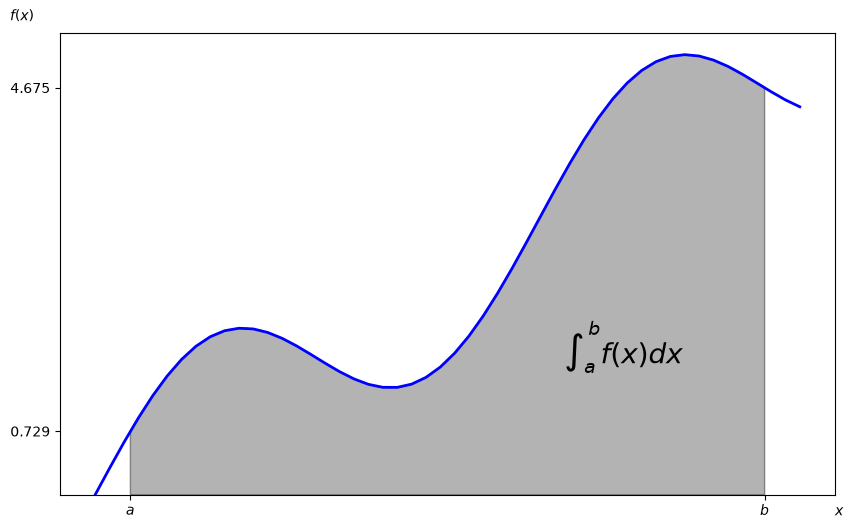

In [84]:
fig, ax = plt.subplots(figsize=(10,6))

plt.plot(x, y, 'b', linewidth=2)
plt.ylim(bottom=0)

verts = [(a, 0)] + list(zip(Ix, Iy)) + [(b, 0)]
poly = Polygon(verts, facecolor='0.7', edgecolor='0.5')
ax.add_patch(poly)

plt.text(0.75 * (a + b), 1.5, r"$\int_a^b f(x)dx$", horizontalalignment='center', fontsize=20)
plt.figtext(0.9, 0.075, '$x$')
plt.figtext(0.075, 0.9, '$f(x)$')

ax.set_xticks((a, b))
ax.set_xticklabels(('$a$', '$b$'))
ax.set_yticks([f(a), f(b)])

plt.show()

### 11.3.1 수치적분

- `scipy.integrate.fixed_quad(func, a, b)`: **가우스 구적법** fixed Gausian quadrature
- `scipy.integrate.quad(func, a, b)`: **적응 구적법** adaptive quadrature

(함수 자체)

In [85]:
sci.fixed_quad(f, a, b)[0]

np.float64(24.366995967084605)

In [86]:
sci.quad(f, a, b)[0]

24.374754718086752

- `scipy.integrate.trapezoid(y, x)`: **사다리꼴법** trapezoidal rule
- `scipy.integrate.simpson(y, x)`: **심슨 방법** Simpson's rule

(데이터 점들)

In [87]:
xi = np.linspace(0.5, 9.5, 25)

In [88]:
sci.trapezoid(f(xi), xi)

np.float64(24.352733271544516)

In [89]:
sci.simpson(f(xi), xi)

np.float64(24.37496418455075)

### 11.3.2 시뮬레이션을 사용한 적분 계산

In [90]:
for i in range(1, 20):
    np.random.seed(1000)
    x = np.random.random(i * 10) * (b - a) + a
    print(np.mean(f(x)) * (b - a))

24.804762279331463
26.522918898332378
26.265547519223976
26.02770339943824
24.99954181440844
23.881810141621663
23.527912274843253
23.507857658961207
23.67236746066989
23.679410416062886
24.424401707879305
24.239005346819056
24.115396924962802
24.424191987566726
23.924933080533783
24.19484212027875
24.117348378249833
24.100690929662274
23.76905109847816


## 11.4 심볼릭 연산

### 11.4.1 심볼릭 연산 기초

- `sympy.Symbol()`: Symbol 객체
- `sympy.pretty()`: 보기 좋은 문자열 형태로 변환

In [91]:
import sympy as sy

In [92]:
x = sy.Symbol('x')
y = sy.Symbol('y')

In [93]:
type(x)

sympy.core.symbol.Symbol

In [94]:
sy.sqrt(x)

sqrt(x)

In [95]:
3 + sy.sqrt(x) - 4 ** 2

sqrt(x) - 13

In [96]:
f = x ** 2 + 3 + 0.5 * x ** 2 + 3 / 2

In [97]:
sy.simplify(f)

1.5*x**2 + 4.5

In [98]:
sy.init_printing(pretty_print=False, use_unicode=False)

In [99]:
print(sy.pretty(f))

     2      
1.5*x  + 4.5


In [100]:
print(sy.pretty(sy.sqrt(x) + 0.5))

  ___      
\/ x  + 0.5


- `sympy.N(expr, n)`: 식 expr을 n자리 정밀도로 수치화

In [101]:
%time pi_str = str(sy.N(sy.pi, 400000))

CPU times: user 74.3 ms, sys: 1.78 ms, total: 76.1 ms
Wall time: 75.7 ms


In [102]:
pi_str[:42]

'3.1415926535897932384626433832795028841971'

In [103]:
pi_str[-40:]

'8245672736856312185020980470362464176199'

In [104]:
%time pi_str.find('0709')

CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 6.91 μs


3641

### 11.4.2 방정식

- `sympy.solve(expr)`: `expr = 0`을 만족하는 해 찾기

In [105]:
sy.solve(x ** 2 - 1)

[-1, 1]

In [106]:
sy.solve(x ** 2 - 1 - 3)

[-2, 2]

In [107]:
sy.solve(x ** 3 + 0.5 * x ** 2 - 1)

[0.858094329496553, -0.679047164748276 - 0.839206763026694*I, -0.679047164748276 + 0.839206763026694*I]

In [108]:
sy.solve(x ** 2 + y ** 2)

[{x: -I*y}, {x: I*y}]

### 11.4.3 적분

- `sympy.Integral(expr, x)`: 부정적분 객체
- `sympy.Integral(expr, (x, a, b))`: 정적분 객체
- `sympy.integrate(expr, x)`: 부정적분 유도
- `sympy.integrate(expr, (x, a, b))`: 정적분 유도

- `SymPy 수식 객체.subs()`: 수식 안의 값을 대입
- `Sympy 수식 객체.subs().evalf()`: 그 값을 소수 근삿값으로 변환


In [109]:
a, b = sy.symbols('a b')

In [110]:
I = sy.Integral(sy.sin(x) + 0.5 * x, (x, a, b))

In [111]:
print(sy.pretty(I))

  b                    
  /                    
 |                     
 |  (0.5*x + sin(x)) dx
 |                     
/                      
a                      


In [112]:
int_func = sy.integrate(sy.sin(x) + 0.5 * x, x)

In [113]:
print(sy.pretty(int_func))

      2         
0.25*x  - cos(x)


In [114]:
Fb = int_func.subs(x, 9.5).evalf()
Fa = int_func.subs(x, 0.5).evalf()

In [115]:
Fb - Fa

24.3747547180867

In [116]:
int_func_limits = sy.integrate(sy.sin(x) + 0.5 * x, (x, a, b))

In [117]:
print(sy.pretty(int_func_limits))

        2         2                  
- 0.25*a  + 0.25*b  + cos(a) - cos(b)


In [118]:
int_func_limits.subs({a : 0.5, b : 9.5}).evalf()

24.3747547180868

In [119]:
sy.integrate(sy.sin(x) + 0.5 * x, (x, 0.5, 9.5))

24.3747547180867

### 11.4.4 미분

- `sympy.diff(expr, x)`: 심볼릭 미분
- `sympy.nsolve(expr, x, x0)`: 방정식을 수치적으로 계산

In [120]:
int_func

0.25*x**2 - cos(x)

In [121]:
int_func.diff()

0.5*x + sin(x)

In [122]:
f = (sy.sin(x) + 0.05 * x ** 2 + sy.sin(y) + 0.05 * y ** 2)

In [123]:
del_x = sy.diff(f, x)
del_x

0.1*x + cos(x)

In [124]:
del_y = sy.diff(f, y)
del_y

0.1*y + cos(y)

In [125]:
xo = sy.nsolve(del_x, -1.5)
xo

-1.42755177876459

In [126]:
yo = sy.nsolve(del_y, -1.5)
yo

-1.42755177876459

In [127]:
f.subs({x: xo, y: yo}).evalf()

-1.77572565314742

In [128]:
xo = sy.nsolve(del_x, 1.5)
xo

1.74632928225285

In [129]:
yo = sy.nsolve(del_y, 1.5)
yo

1.74632928225285

In [130]:
f.subs({x: xo, y: yo}).evalf()

2.27423381055640